# Supervisor Agent란?

**Supervisor Agent**는 Hierarchical Agent의 특수한 형태로, 여러 전문 에이전트들을 **관리하고 조율**하는 역할을 합니다.

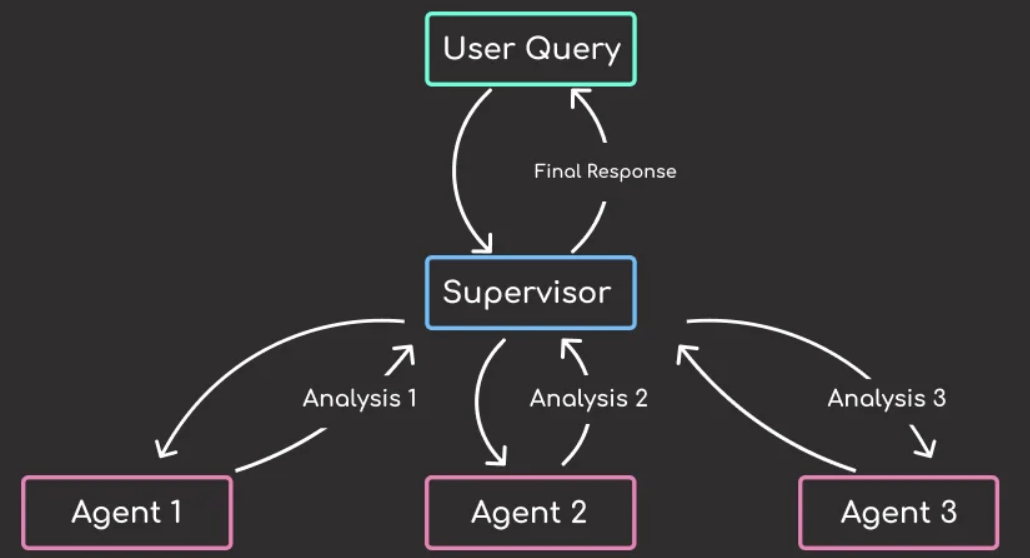



## 주요 특징
1. **중앙 집중식 제어**: Supervisor가 전체 워크플로우를 관리
2. **동적 작업 배분**: 상황에 따라 적절한 에이전트에게 작업 할당
3. **결과 종합**: 여러 에이전트의 결과를 수집하고 통합
4. **순차적 조율**: 필요시 에이전트 간 작업 순서 조정

## vs. 단순 Hierarchical Agent
- **Hierarchical**: 단순히 작업을 분류하여 해당 에이전트로 전달 (1회성)
- **Supervisor**: 전체 프로세스를 관리하며, 여러 에이전트를 순차적으로 호출하고 결과를 통합 (다단계)

# Supervisor Agents - 블로그 콘텐츠 제작 시스템

Supervisor Agent 패턴을 활용하여 블로그 콘텐츠를 자동으로 제작하는 시스템을 구현합니다.


## 시스템 구성

### 에이전트 구조
```
                    Supervisor Agent
                    (콘텐츠 제작 관리자)
                           |
         +-----------------+-----------------+
         |                 |                 |
    Research Agent    Writer Agent      SEO Agent
    (자료 조사)        (초안 작성)       (SEO 최적화)
         |                 |                 |
         +-----------------+-----------------+
                           |
                    Editor Agent
                    (최종 편집)
```

### 작업 흐름
1. **Supervisor**: 블로그 주제를 분석하고 작업 계획 수립
2. **Research Agent**: 주제 관련 정보 조사 및 핵심 포인트 추출
3. **Writer Agent**: 조사 자료를 바탕으로 초안 작성
4. **SEO Agent**: 키워드 최적화 및 SEO 권장사항 제시
5. **Editor Agent**: 최종 편집 및 교정
6. **Supervisor**: 모든 결과를 종합하여 최종 콘텐츠 생성


## 학습 목표

- Supervisor Agent의 역할과 책임 이해
- 다단계 워크플로우 설계 및 구현
- 에이전트 간 데이터 전달 및 상태 관리
- 동적 작업 조율 (Dynamic Task Orchestration)


## 1단계: LLM 모델 초기화


In [1]:
from langchain_ollama.chat_models import ChatOllama

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.7,  # 창의적인 콘텐츠 생성을 위해 약간 높임
    top_p=1.0,
    keep_alive="5m"
)


## 2단계: 상태 정의 (State Management)

Supervisor Agent 시스템에서는 여러 에이전트가 순차적으로 작업하므로, 각 단계의 결과를 저장할 수 있는 복잡한 상태 구조가 필요합니다.


In [2]:
from typing import TypedDict, Literal

# total=False는 TypedDict의 모든 필드를 선택적(optional)으로 만드는 옵션
class ContentState(TypedDict, total=False):
    """
    블로그 콘텐츠 제작 시스템의 상태를 정의하는 클래스
    """
    # 입력
    topic: str                      # 블로그 주제
    target_audience: str            # 타겟 독자층
    
    # Supervisor 관리
    current_step: str               # 현재 진행 단계
    next_agent: str                 # 다음 실행할 에이전트
    
    # 각 에이전트의 작업 결과
    research_data: str              # Research Agent의 조사 결과
    draft_content: str              # Writer Agent의 초안
    seo_recommendations: str        # SEO Agent의 권장사항
    edited_content: str             # Editor Agent의 최종 편집본
    
    # 최종 출력
    final_blog_post: str            # 완성된 블로그 포스트
    status: Literal['in_progress', 'completed']  # 작업 상태

## 3단계: 전문 에이전트 정의

각 에이전트는 특정 영역의 전문가 역할을 수행합니다.


### Research Agent (조사 에이전트)

주제에 대한 핵심 정보를 조사하고 정리합니다.


In [3]:
from langchain_core.messages import HumanMessage, SystemMessage

def research_agent(state: ContentState) -> ContentState:
    """
    주제에 대한 조사를 수행하는 에이전트
    """
    topic = state["topic"]
    target_audience = state["target_audience"]
    
    messages = [
        SystemMessage(content="""
            당신은 전문 리서처입니다.
            주어진 주제에 대해 다음 항목을 조사하여 정리하세요:
            
            1. 주제의 핵심 개념 및 정의
            2. 주요 트렌드 및 최신 동향
            3. 독자들이 궁금해할 만한 점 3가지
            4. 실용적인 팁이나 인사이트
            5. 관련 통계나 데이터 (있다면)
            
            간결하고 구조화된 형태로 작성하세요."""),
        HumanMessage(content=f"""
            주제: {topic}
            타겟 독자: {target_audience}
            
            위 주제에 대해 조사해주세요.""")
    ]
    
    response = llm.invoke(messages)
    research_data = response.content
    
    print("[Research Agent] 조사 완료")
    print(f"조사 결과 길이: {len(research_data)} 자")
    
    return {
        **state,
        "research_data": research_data,
        "current_step": "research_completed",
        "next_agent": "writer"
    }


블로그 초안을 작성하는 에이전트

In [4]:
def writer_agent(state: ContentState) -> ContentState:
    """
    블로그 초안을 작성하는 에이전트
    """
    topic = state["topic"]
    research_data = state["research_data"]
    target_audience = state["target_audience"]
    
    messages = [
        SystemMessage(content="""
            당신은 전문 블로그 작가입니다.
            조사 자료를 바탕으로 매력적인 블로그 포스트 초안을 작성하세요.
            
            구조:
            1. 흥미를 끄는 서론
            2. 본론 (3-4개 섹션)
            3. 실용적인 조언이나 팁
            4. 요약 및 결론
            
            문체:
            - 친근하고 읽기 쉬운 문체
            - 독자에게 직접 말하는 듯한 톤
            - 적절한 예시와 설명 포함"""),
        HumanMessage(content=f"""
            주제: {topic}
            타겟 독자: {target_audience}
            
            조사 자료:
            {research_data}
            
            위 자료를 바탕으로 블로그 포스트 초안을 작성해주세요.""")
    ]
    
    response = llm.invoke(messages)
    draft_content = response.content
    
    print("[Writer Agent] 초안 작성 완료")
    print(f"초안 길이: {len(draft_content)} 자")
    
    return {
        **state,
        "draft_content": draft_content,
        "current_step": "draft_completed",
        "next_agent": "seo"
    }


SEO 최적화 권장사항을 제공하는 에이전트

In [5]:
def seo_agent(state: ContentState) -> ContentState:
    """
    SEO 최적화 권장사항을 제공하는 에이전트
    """
    topic = state["topic"]
    draft_content = state["draft_content"]
    
    messages = [
        SystemMessage(content="""
            당신은 SEO 전문가입니다.
            블로그 초안을 분석하여 검색엔진 최적화 권장사항을 제시하세요.
            
            분석 항목:
            1. 추천 키워드 5-7개 (주 키워드 + 롱테일 키워드)
            2. 메타 디스크립션 제안 (150-160자)
            3. 제목 개선안 (SEO 친화적)
            4. 헤딩 구조 개선 제안
            5. 내부/외부 링크 권장사항
            
            간결하고 실행 가능한 조언을 제공하세요."""),
        HumanMessage(content=f"""
            주제: {topic}
            
            초안:
            {draft_content[:1000]}... (초반부)
            
            SEO 최적화 권장사항을 제시해주세요.""")
    ]
    
    response = llm.invoke(messages)
    seo_recommendations = response.content
    
    print("[SEO Agent] SEO 분석 완료")
    
    return {
        **state,
        "seo_recommendations": seo_recommendations,
        "current_step": "seo_completed",
        "next_agent": "editor"
    }


### Editor Agent (편집 에이전트)

초안과 SEO 권장사항을 반영하여 최종 편집본을 만듭니다.


In [6]:
def editor_agent(state: ContentState) -> ContentState:
    """
    최종 편집 및 교정을 수행하는 에이전트
    """
    draft_content = state["draft_content"]
    seo_recommendations = state["seo_recommendations"]
    
    messages = [
        SystemMessage(content="""
            당신은 전문 에디터입니다.
            초안을 검토하고 SEO 권장사항을 반영하여 최종 편집본을 만드세요.
            
            편집 작업:
            1. 문법 및 맞춤법 교정
            2. 문장 흐름 개선
            3. SEO 키워드 자연스럽게 삽입
            4. 제목과 소제목 최적화
            5. 가독성 향상 (단락 나누기, 불릿 포인트 활용)
            
            원본의 핵심 메시지는 유지하되, 더 세련되고 전문적으로 다듬으세요."""),
        HumanMessage(content=f"""
            초안:
            {draft_content}
            
            SEO 권장사항:
            {seo_recommendations}
            
            위 내용을 반영하여 최종 편집본을 작성해주세요.""")
    ]
    
    response = llm.invoke(messages)
    edited_content = response.content
    
    print("[Editor Agent] 최종 편집 완료")
    
    return {
        **state,
        "edited_content": edited_content,
        "current_step": "editing_completed",
        "next_agent": "supervisor"
    }


## 4단계: Supervisor Agent 정의

**핵심!** Supervisor Agent는 전체 워크플로우를 관리하고 조율합니다.


In [7]:
def supervisor_agent(state: ContentState) -> ContentState:
    """
    전체 콘텐츠 제작 프로세스를 관리하는 Supervisor Agent
    """
    current_step = state.get("current_step", "start")
    
    print(f"\n[Supervisor Agent] 현재 단계: {current_step}")
    
    # 시작 단계: 작업 계획 수립
    if current_step == "start":
        print("[Supervisor] 작업 계획 수립 중...")
        print("  → 1단계: Research Agent 호출 예정")
        print("  → 2단계: Writer Agent 호출 예정")
        print("  → 3단계: SEO Agent 호출 예정")
        print("  → 4단계: Editor Agent 호출 예정")
        print("  → 5단계: 최종 결과 종합 예정")
        
        return {
            **state,
            "current_step": "planned",
            "next_agent": "research",
            "status": "in_progress"
        }
    
    # 모든 에이전트 작업 완료: 최종 결과 종합
    elif current_step == "editing_completed":
        print("[Supervisor] 모든 에이전트 작업 완료. 최종 결과 종합 중...")
        
        final_blog_post = f"""
            # 블로그 콘텐츠 제작 완료

            ## 메타 정보
            **주제:** {state['topic']}
            **타겟 독자:** {state['target_audience']}

            ---

            ## 최종 콘텐츠

            {state['edited_content']}

            ---

            ## SEO 권장사항

            {state['seo_recommendations']}

            ---

            ## 제작 프로세스
                조사 완료 (Research Agent)
                초안 작성 완료 (Writer Agent)
                SEO 분석 완료 (SEO Agent)
                최종 편집 완료 (Editor Agent)
        """
        
        print("[Supervisor] 최종 블로그 포스트 생성 완료!")
        
        return {
            **state,
            "final_blog_post": final_blog_post,
            "current_step": "completed",
            "next_agent": "end",
            "status": "completed"
        }
    
    # 기타 단계: 다음 에이전트로 진행
    else:
        return state


## 5단계: 조건부 라우팅

In [8]:
from typing import Literal

def route_to_next_agent(state: ContentState) -> Literal["research", "writer", "seo", "editor", "supervisor", "end"]:
    """
    Supervisor의 지시에 따라 다음 에이전트로 라우팅
    """
    next_agent = state.get("next_agent", "research")
    
    print(f"[Router] 다음 에이전트로 이동: {next_agent}")
    
    if next_agent == "end":
        return "end"
    
    return next_agent


## 6단계: 그래프 구성

Supervisor Agent 패턴의 핵심: **순환 구조**를 만들어 Supervisor가 각 단계를 조율합니다.


In [9]:
from langgraph.graph import StateGraph, END, START

# StateGraph 생성
workflow = StateGraph(ContentState)

# 모든 노드 추가
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("research", research_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("seo", seo_agent)
workflow.add_node("editor", editor_agent)

# 시작점: Supervisor로 시작
workflow.add_edge(START, "supervisor")

# Supervisor에서 조건부 라우팅
workflow.add_conditional_edges(
    "supervisor",
    route_to_next_agent,
    {
        "research": "research",
        "writer": "writer",
        "seo": "seo",
        "editor": "editor",
        "supervisor": "supervisor",
        "end": END
    }
)

# 각 전문 에이전트는 작업 후 다음 에이전트로 직접 이동
# (Supervisor를 거치지 않고 효율성 향상)
workflow.add_edge("research", "writer")
workflow.add_edge("writer", "seo")
workflow.add_edge("seo", "editor")

# Editor는 작업 후 Supervisor에게 보고
workflow.add_edge("editor", "supervisor")

# 그래프 컴파일
app = workflow.compile()

print("Supervisor Agent 시스템 구성 완료!")


Supervisor Agent 시스템 구성 완료!


## 7단계: 그래프 시각화


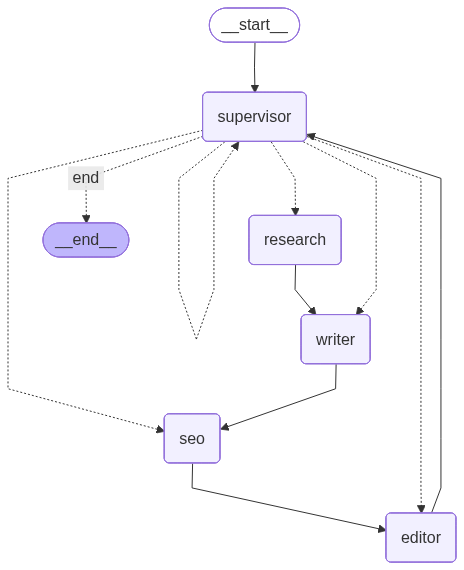

In [10]:
from IPython.display import Image, display

try:
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 8단계: 시스템 테스트

실제 블로그 주제로 전체 프로세스를 테스트해봅니다.


### 테스트 케이스: LangChain 가이드 블로그


In [11]:
# 초기 상태 설정
initial_state = {
    "topic": "개발자를 위한 LangChain 시작 가이드",
    "target_audience": "Python을 다룰 줄 아는 주니어-미들 레벨 개발자"
}

print("=" * 80)
print("블로그 콘텐츠 제작 시작!")
print("=" * 80)
print(f"주제: {initial_state['topic']}")
print(f"타겟 독자: {initial_state['target_audience']}")
print("=" * 80)

# 그래프 실행
result = app.invoke(initial_state)

print("\n" + "=" * 80)
print("블로그 콘텐츠 제작 완료!")
print("=" * 80)


블로그 콘텐츠 제작 시작!
주제: 개발자를 위한 LangChain 시작 가이드
타겟 독자: Python을 다룰 줄 아는 주니어-미들 레벨 개발자

[Supervisor Agent] 현재 단계: start
[Supervisor] 작업 계획 수립 중...
  → 1단계: Research Agent 호출 예정
  → 2단계: Writer Agent 호출 예정
  → 3단계: SEO Agent 호출 예정
  → 4단계: Editor Agent 호출 예정
  → 5단계: 최종 결과 종합 예정
[Router] 다음 에이전트로 이동: research
[Research Agent] 조사 완료
조사 결과 길이: 2337 자
[Writer Agent] 초안 작성 완료
초안 길이: 2950 자
[SEO Agent] SEO 분석 완료
[Editor Agent] 최종 편집 완료

[Supervisor Agent] 현재 단계: editing_completed
[Supervisor] 모든 에이전트 작업 완료. 최종 결과 종합 중...
[Supervisor] 최종 블로그 포스트 생성 완료!
[Router] 다음 에이전트로 이동: end

블로그 콘텐츠 제작 완료!


### 최종 결과 확인


In [12]:
# 최종 블로그 포스트 출력
print(result["final_blog_post"])



            # 블로그 콘텐츠 제작 완료

            ## 메타 정보
            **주제:** 개발자를 위한 LangChain 시작 가이드
            **타겟 독자:** Python을 다룰 줄 아는 주니어-미들 레벨 개발자

            ---

            ## 최종 콘텐츠

            ## LangChain 시작 가이드: 개발자를 위한 LLM 활용 튜토리얼

**LLM의 잠재력을 최대한 활용하는 방법, LangChain으로 시작하세요!**

ChatGPT, Bard와 같은 LLM(Large Language Model)의 강력한 기능을 활용하여 애플리케이션을 개발하고 싶으신가요? LangChain은 LLM의 잠재력을 최대한 활용할 수 있도록 설계된 강력한 프레임워크입니다. 이 가이드에서는 LangChain의 핵심 개념을 소개하고, 여러분이 LLM을 활용한 애플리케이션 개발을 시작할 수 있도록 단계별로 안내합니다. 챗봇 개발, 문서 요약, 데이터 추출 등 다양한 프로젝트를 시작해보세요!

**1. LangChain이란 무엇일까요?**

LangChain은 LLM을 기반으로 애플리케이션을 구축하기 위한 프레임워크입니다. GPT, PaLM, Claude 등 다양한 LLM을 쉽게 활용하여 질문 응답, 챗봇, 문서 요약, 데이터 추출 등 다양한 작업을 자동화할 수 있습니다. 마치 레고 블록처럼, LLM의 잠재력을 최대한 활용하여 원하는 애플리케이션을 만들 수 있도록 설계되었습니다. LangChain은 LLM을 더 쉽게 접근하고 활용할 수 있도록 다양한 도구와 기능을 제공합니다.

**2. LangChain의 핵심 구성 요소**

LangChain은 다음과 같은 핵심 구성 요소로 이루어져 있습니다.

* **모델 (Models):** OpenAI의 GPT, Google의 PaLM, Anthropic의 Claude 등 다양한 LLM을 통합하여 사용합니다. 여러분의 프로젝트에 가장 적합한 LLM을 선택

### 단계별 작업 결과 확인


In [13]:
print("\nResearch Agent 조사 결과:")
print("-" * 80)
print(result["research_data"][:500] + "...\n")


Research Agent 조사 결과:
--------------------------------------------------------------------------------
## 개발자를 위한 LangChain 시작 가이드: 핵심 정리 (주니어-미들 레벨 개발자 대상)

**1. 주제의 핵심 개념 및 정의**

* **LangChain:** LangChain은 대규모 언어 모델(LLM)을 기반으로 애플리케이션을 구축하기 위한 프레임워크입니다. LLM의 강력한 기능을 활용하여 질문 응답, 챗봇, 문서 요약, 데이터 추출 등 다양한 작업을 자동화하고, LLM을 외부 데이터 및 도구와 연결하여 더욱 풍부하고 정확한 결과를 얻도록 돕습니다.
* **핵심 구성 요소:**
    * **모델 (Models):** OpenAI의 GPT, Google의 PaLM 등 다양한 LLM을 통합하여 사용합니다.
    * **프롬프트 (Prompts):** LLM에게 제공하는 입력 텍스트로, 원하는 결과를 얻기 위한 지시사항을 담고 있습니다.
    * **체인 (Chains):** 여러 구성 요소(모델, 프롬프트, 데이터 연결 등)를 연결하여 일련의 작업을 수행하는 흐름을 ...



In [14]:
print("\nWriter Agent 초안:")
print("-" * 80)
print(result["draft_content"][:500] + "...\n")


Writer Agent 초안:
--------------------------------------------------------------------------------
## 개발자를 위한 LangChain 시작 가이드: LLM의 잠재력을 최대한 활용하기

안녕하세요, 여러분! 주니어~미들 레벨 개발자 여러분, 혹시 LLM(Large Language Model)의 강력한 기능에 매료되어 어떻게 활용할 수 있을지 고민하고 계신가요? LangChain은 바로 여러분을 위한 솔루션입니다. 이 가이드에서는 LangChain의 핵심 개념을 소개하고, 여러분이 LLM을 활용한 애플리케이션 개발을 시작할 수 있도록 도와드리겠습니다.

**1. LangChain이란 무엇일까요?**

LangChain은 LLM을 기반으로 애플리케이션을 구축하기 위한 강력한 프레임워크입니다. GPT, PaLM 등 다양한 LLM을 쉽게 활용하여 질문 응답, 챗봇, 문서 요약, 데이터 추출 등 다양한 작업을 자동화할 수 있습니다. 마치 레고 블록처럼, LLM의 잠재력을 최대한 활용하여 원하는 애플리케이션을 만들 수 있도록 설계되었습니다.

**2. LangChain의 핵심 구성 요소**...



In [15]:
print("\nSEO Agent 권장사항:")
print("-" * 80)
print(result["seo_recommendations"][:500] + "...\n")


SEO Agent 권장사항:
--------------------------------------------------------------------------------
## 블로그 초안 분석: 개발자를 위한 LangChain 시작 가이드 - SEO 최적화 권장사항

**분석 결과:**

이 블로그 초안은 LangChain의 기본 개념을 잘 설명하고 있지만, SEO 관점에서 몇 가지 개선할 부분이 있습니다. 특히 개발자 커뮤니티의 검색 의도를 파악하고, 관련 키워드를 활용하여 검색 결과 상위에 노출될 수 있도록 수정해야 합니다.

**1. 추천 키워드 (주 키워드 + 롱테일 키워드):**

* **주 키워드:** LangChain
* **롱테일 키워드:**
    * LangChain 시작 가이드
    * LangChain 개발 방법
    * LangChain 사용 예제
    * LangChain 튜토리얼
    * LangChain LLM 적용
    * LangChain 챗봇 개발
    * LangChain 문서 요약

**2. 메타 디스크립션 제안 (150-160자):**

"LangChain 시작 가이드! LLM(Large Langua...



In [16]:
print("\nEditor Agent 최종 편집본:")
print("-" * 80)
print(result["edited_content"][:500] + "...\n")



Editor Agent 최종 편집본:
--------------------------------------------------------------------------------
## LangChain 시작 가이드: 개발자를 위한 LLM 활용 튜토리얼

**LLM의 잠재력을 최대한 활용하는 방법, LangChain으로 시작하세요!**

ChatGPT, Bard와 같은 LLM(Large Language Model)의 강력한 기능을 활용하여 애플리케이션을 개발하고 싶으신가요? LangChain은 LLM의 잠재력을 최대한 활용할 수 있도록 설계된 강력한 프레임워크입니다. 이 가이드에서는 LangChain의 핵심 개념을 소개하고, 여러분이 LLM을 활용한 애플리케이션 개발을 시작할 수 있도록 단계별로 안내합니다. 챗봇 개발, 문서 요약, 데이터 추출 등 다양한 프로젝트를 시작해보세요!

**1. LangChain이란 무엇일까요?**

LangChain은 LLM을 기반으로 애플리케이션을 구축하기 위한 프레임워크입니다. GPT, PaLM, Claude 등 다양한 LLM을 쉽게 활용하여 질문 응답, 챗봇, 문서 요약, 데이터 추출 등 다양한 작업을 자동화할 수 있습니다....

